In [14]:
cd notebooks/Cu_example/

/home/mb/MEGAsync/academic_work/projects/Atomistic_continuation/code/LACT/notebooks/Cu_example


/home/mb/MEGAsync/academic_work/projects/Atomistic_continuation/proper_lammps/.venv/lib64/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import lammps

In [8]:
pip install -e .

Obtaining file:///home/mb/MEGAsync/academic_work/projects/Atomistic_continuation/code/LACT
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for LACT (pyproject.toml) ... done
  Created wheel for LACT: filename=LACT-0.0.1-0.editable-py3-none-any.whl size=2681 sha256=594c53405f55037c61c571cc228286b598ab92741c425a38fce5f15d9b1e436e
  Stored in directory: /tmp/pip-ephem-wheel-cache-6zmo1hnv/wheels/09/79/07/8ebe65b51aa8566225db4d278605d1c2c4008f1f7df7278222
Successfully built LACT

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
# To install the repo, run (potentially pwd() needs to be adjusted)
pip install -e .

SyntaxError: invalid syntax (253813194.py, line 2)

In [1]:
import LACT
from LACT import *

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from lammps import lammps, LMP_STYLE_ATOM, LMP_TYPE_VECTOR, LMP_TYPE_ARRAY
from ctypes import c_double, c_int

import scipy
from scipy import optimize

In [3]:
lmp_initialise = '''
# ------------------------ INITIALIZATION ----------------------------
processors    * * *
units         metal
dimension    3
boundary    p    p    p
atom_style   atomic
atom_modify map yes


box        tilt large
#--------------------------- LAMMPS Data File--------------------------
read_data    input_data/proper_thick_domain.lmp
#read_data    input_data/thicker_domain.lmp
#read_data    input_data/4b_step.lmp
change_box    all triclinic
reset_atom_ids sort yes

#--------------
pair_style    eam/alloy
pair_coeff    * * input_data/Cu_mishin1.eam.alloy Cu

#-------------------Various continuation commands----------------------
compute forces all property/atom fx fy fz
compute ids all property/atom id
compute x_check all property/atom x y z
#atom_modify map yes
'''

In [4]:
lmp = lammps(cmdargs=['-screen', 'none'])

lmp.commands_string(lmp_initialise)

In [5]:
def change_box_command(limits,direction="x"):
    command = f"""
     change_box all {direction} final {limits[0]} {limits[1]} units box
    """
    return command

def update_command_box_x(x,box_size):
    direction = "x"
    i = 0 if direction=="x" else 1 if direction=="y" else 2
    return change_box_command([box_size[0][i]+x,box_size[1][i]-x],direction=direction)

In [6]:
system = atom_cont_system(lmp,update_command_box_x)

In [7]:
system.natoms

185200

In [ ]:
system.quasi_static_run(0.0, 0.05, 2, verbose=True)


        %%%%%%%%%%%%%%%%%%%%%%%%%%%
        A quasi-static run: adjust μ and minimise in LAMMPS
        
Iteration step:  1   , Solution step:  1   , Continuation parameter:  0.0


In [21]:
ds_default = 2e0
ds_smallest = 1e-3
ds_largest = 4e0

system.continuation_run(25,
                     ds_default = ds_default,
                     ds_smallest = ds_smallest,
                     ds_largest = ds_largest,
                     verbose=True)


        %%%%%%%%%%%%%%%%%%%%%%%%%%%
        A continuation run: solve extended system to find points on the solution path.
        


/home/mb/MEGAsync/academic_work/projects/Atomistic_continuation/proper_lammps/.venv/lib64/python3.11/site-packages/scipy/optimize/_nonlin.py:374: RuntimeWarning: invalid value encountered in scalar divide
  and dx_norm/self.x_rtol <= x_norm))


0:  |F(x)| = 4.62323e-07; step 1
Iteration step:  1   , Solution step:  3   , Continuation parameter:  0.09807377153238556
0:  |F(x)| = 1.12659e-06; step 1
Iteration step:  2   , Solution step:  4   , Continuation parameter:  0.14616392879584147
0:  |F(x)| = 1.29262e-06; step 1
Iteration step:  3   , Solution step:  5   , Continuation parameter:  0.19428221513386673
0:  |F(x)| = 1.02476e-06; step 1
Iteration step:  4   , Solution step:  6   , Continuation parameter:  0.242406832696598
0:  |F(x)| = 1.39848e-06; step 1
Iteration step:  5   , Solution step:  7   , Continuation parameter:  0.2905465629552452
0:  |F(x)| = 1.41045e-06; step 1
ds doubled, now equal to  4.0 .
Iteration step:  6   , Solution step:  8   , Continuation parameter:  0.33870003912481444
0:  |F(x)| = 2.79008e-06; step 1
Iteration step:  7   , Solution step:  9   , Continuation parameter:  0.43502619100163725
0:  |F(x)| = 4.90326e-06; step 1
Iteration step:  8   , Solution step:  10   , Continuation parameter:  0.5314

In [22]:
path = 'dumps/thin_domain/interface_tests/'
file_name = 'dump'

In [23]:
system.dump_data(path,file_name)

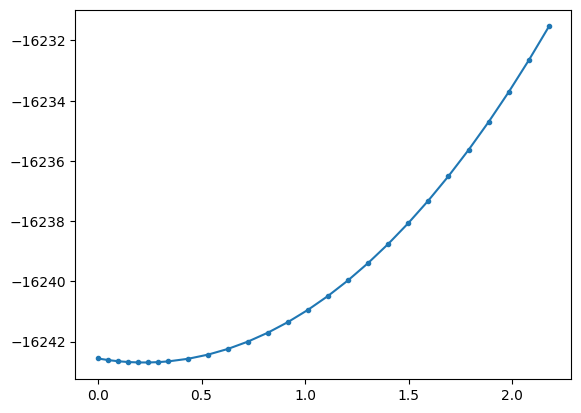

In [24]:
system.compute_energies()
μs = [Y[-1] for Y in system.data["Y_s"]]
plt.plot(μs,system.data["energies"],'.-')